The bad result is:
{}


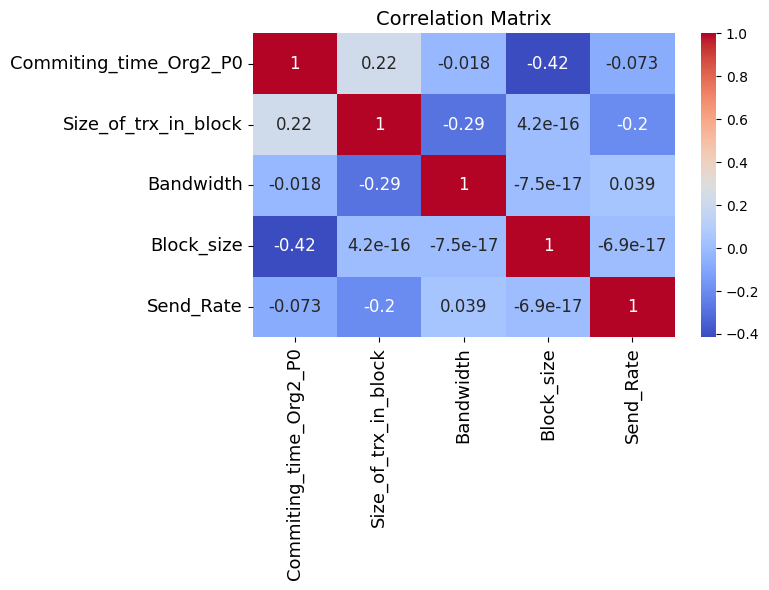

Correlation with 'Commiting_time_Org2_P0':
Commiting_time_Org2_P0    1.000000
throuout                  0.417891
Size_of_trx_in_block      0.222841
Bandwidth                -0.018246
Send_Rate                -0.073265
latancy                  -0.324396
Block_size               -0.415916
Name: Commiting_time_Org2_P0, dtype: float64

Feature Importances:
                Feature  Importance
2            Block_size    0.864615
0  Size_of_trx_in_block    0.058720
3             Send_Rate    0.051203
1             Bandwidth    0.025461

Top 2 Features:
['Block_size', 'Size_of_trx_in_block']


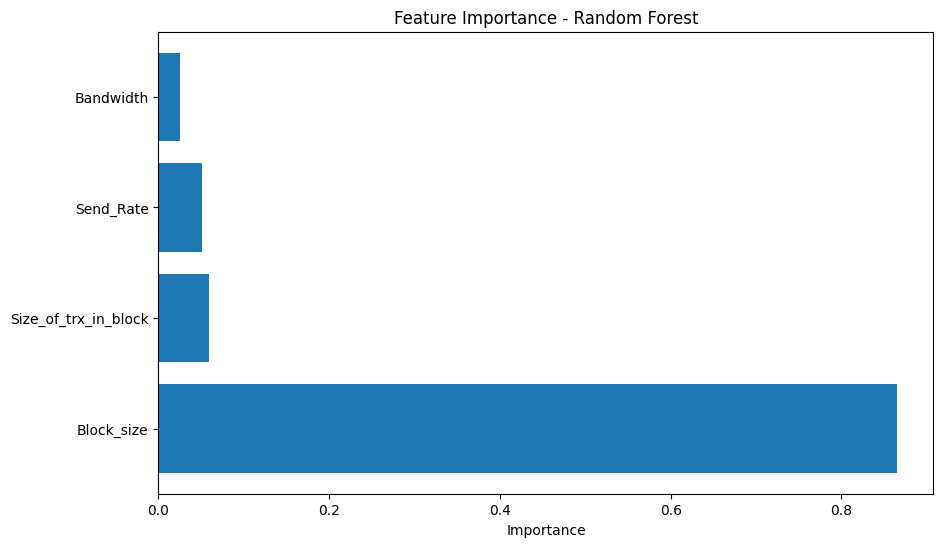

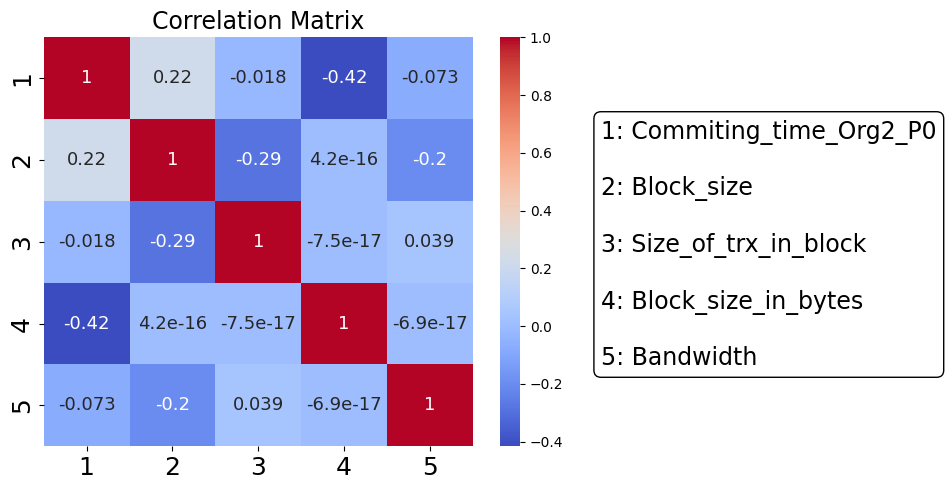

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                                8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                          1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                    5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Commiting_time_Org2_P0": [
           0.017529809,
0.021938776,
0.023378901,
0.025713038,
0.024838619,
0.017197545,
0.015670965,
0.015858449,
0.01664869,
0.016177148,
0.014817032,
0.016343263,
0.016032416,
0.016461766,
0.016460882,
0.022594437,
0.027311158,
0.03025193,
0.032223663,
0.029934389,
0.022762114,
0.020303043,
0.019621506,
0.019409037,
0.018538617,
0.017278939,
0.017332212,
0.01534641,
0.016316109,
0.015706572,
0.017940609,
0.021846025,
0.022321166,
0.025274023,
0.024016704,
0.016132153,
0.015401604,
0.017417978,
0.016898266,
0.015696838,
0.015261357,
0.016403074,
0.01632151,
0.016590175,
0.01662598,
0.017687664,
0.021560627,
0.022559565,
0.025206934,
0.02594691,
0.019210041,
0.016728941,
0.01725997,
0.016110157,
0.01626395,
0.015085306,
0.016734443,
0.015959147,
0.016437752,
0.016163708,
0.017564047,
0.021610468,
0.023452625,
0.025782973,
0.025248889,
0.017117122,
0.016409348,
0.017041432,
0.01637782,
0.015669746,
0.014797142,
0.017739744,
0.016641562,
0.01690961,
0.016553512,
0.017866551,
0.021594457,
0.02325814,
0.02448019,
0.025082086,
0.016749766,
0.016198721,
0.01650531,
0.017194957,
0.015715462,
0.014999206,
0.017049717,
0.016571831,
0.017150067,
0.016709285,
0.017568073,
0.02176018,
0.02215002,
0.027672023,
0.023672196,
0.017536104,
0.015932465,
0.015524958,
0.017948482,
0.016066336,
0.014924519,
0.016251635,
0.015669321,
0.017219238,
0.016896229,
0.017343495,
0.021520656,
0.022640045,
0.026732305,
0.023355873,
0.017874859,
0.015905887,
0.016485589,
0.01708611,
0.01483046,
0.015346326,
0.016354432,
0.016035172,
0.016251364,
0.016440137,
0.017406,
0.021556132,
0.022651819,
0.025242663,
0.024654647,
0.019431072,
0.017265246,
0.016012587,
0.016304032,
0.015654487,
0.014873577,
0.017635105,
0.017217376,
0.01686567,
0.016960807,
0.017876405,
0.021908083,
0.023211276,
0.025823573,
0.024047621,
0.017823581,
0.015485842,
0.016216671,
0.017005058,
0.016169092,
0.015348107,
0.016531872,
0.01588436,
0.016690068,
0.017008327,
0.017876405,
0.021908083,
0.023211276,
0.025823573,
0.024047621,
0.017823581,
0.015485842,
0.016216671,
0.017005058,
0.016169092,
0.015348107,
0.016531872,
0.01588436,
0.016690068,
0.017008327,
0.017711922,
0.021692579,
0.022666612,
0.02621562,
0.025343096,
0.016764704,
0.016845705,
0.01714908,
0.01639525,
0.015919027,
0.015291192,
0.016744561,
0.016219371,
0.016772703,
0.016086134,
0.017901007,
0.021671968,
0.023242853,
0.025767137,
0.02512238,
0.019181608,
0.016076795,
0.016136169,
0.0167143,
0.01609353,
0.014798071,
0.016912603,
0.016750229,
0.016403092,
0.016426898,
0.017923948,
0.022201201,
0.024264511,
0.026190916,
0.025572264,
0.018130385,
0.017854673,
0.015727004,
0.017279483,
0.016292473,
0.015079825,
0.016953357,
0.015771867,
0.018119745,
0.017200751,
0.018326915,
0.021973279,
0.02391759,
0.027969886,
0.027689301,
0.01837615,
0.016730824,
0.017217303,
0.01670336,
0.015207717,
0.014624298,
0.016172522,
0.016479807,
0.017215152,
0.016622858,
0.017847368,
0.022358261,
0.023981985,
0.025800224,
0.024161212,
0.016905237,
0.015943773,
0.016946703,
0.016860945,
0.016378323,
0.015220591,
0.017334922,
0.017015142,
0.01633124,
0.017258287,
0.017235383,
0.021282037,
0.021725758,
0.02601002,
0.024707061,
0.016954358,
0.016968418,
0.016625231,
0.016796785,
0.016500333,
0.015228962,
0.016818262,
0.017027429,
0.016219521,
0.015367002,
0.018114055,
0.021806416,
0.022835667,
0.026629187,
0.024660723,
0.016925734,
0.016263926,
0.016940866,
0.015904351,
0.014003863,
0.015008221,
0.016624018,
0.017010502,
0.01649928,
0.018751043,
0.020025513,
0.023649244,
0.024530909,
0.02780448,
0.025854382,
0.017781573,
0.016749641,
0.019960289,
0.017336755,
0.016758601,
0.015278344,
0.018289275,
0.016639616,
0.018005553,
0.017624452,
0.018863759,
0.023506072,
0.026450603,
0.026709413,
0.02782821,
0.019278471,
0.018504493,
0.017449234,
0.017369648,
0.016419155,
0.015937549,
0.018326161,
0.017317716,
0.017184068,
0.017912568,
0.017585657,
0.022433643,
0.023605158,
0.027119001,
0.025343681,
0.016686373,
0.01893581,
0.017305736,
0.016906672,
0.016384062,
0.015094916,
0.01716401,
0.016726275,
0.019846591,
0.016459411,
0.018390608,
0.022414805,
0.023228928,
0.026356135,
0.026669298,
0.017726913,
0.016480215,
0.017291478,
0.015958111,
0.015539629,
0.015628733,
0.017422579,
0.017064317,
0.016359368,
0.016666593,
0.017881592,
0.022362063,
0.024299329,
0.027275605,
0.026392251,
0.01808332,
0.01856562,
0.017216248,
0.01642925,
0.015395839,
0.015512473,
0.017427545,
0.016102903,
0.017528484,
0.016593324,
0.017927474,
0.021773608,
0.023129271,
0.027169075,
0.02698029,
0.017820064,
0.016294405,
0.017072923,
0.017289073,
0.01628924,
0.015276322,
0.017481005,
0.016871443,
0.017091785,
0.015475379,
0.018415012,
0.022495005,
0.024072046,
0.028569828,
0.027307185,
0.017864782,
0.01781282,
0.019375676,
0.02488112,
0.018942943,
0.016273428,
0.017898226,
0.017413631,
0.017014542,
0.018734922,
0.01849036,
0.023124644,
0.024269359,
0.027639492,
0.028250194,
0.018563796,
0.017989866,
0.01782399,
0.017482251,
0.015770205,
0.016363692,
0.019174639,
0.017645449,
0.016996744,
0.017492362,
0.018784881,
0.022944018,
0.025229428,
0.028817328,
0.027259007,
0.018634491,
0.018282144,
0.016922416,
0.017377774,
0.017383094,
0.015650553,
0.018666996,
0.017647781,
0.016923582,
0.017933326,
0.018004611,
0.022041577,
0.023465618,
0.026682724,
0.028332322,
0.018505866,
0.016998906,
0.017632445,
0.018487938,
0.016188022,
0.015265313,
0.017306158,
0.017254959,
0.017383524,
0.017695155,
0.018812778,
0.023722053,
0.024707154,
0.027769429,
0.024911504,
0.019913289,
0.016881843,
0.016725308,
0.018389312,
0.017119037,
0.016300667,
0.018816631,
0.017832921,
0.017582122,
0.01878208,
0.018971125,
0.022469625,
0.024954311,
0.027175829,
0.02625841,
0.020952992,
0.017260875,
0.017716327,
0.016630021,
0.017172612,
0.016231802,
0.017438625,
0.018458575,
0.017447002,
0.016903539,
0.018360814,
0.022852281,
0.024685784,
0.028927037,
0.026747184,
0.020787148,
0.017993352,
0.017358299,
0.017538115,
0.015197822,
0.016308056,
0.01776451,
0.016472141,
0.017138265,
0.017919295,
0.017940288,
0.022602434,
0.02361869,
0.02702057,
0.024161571,
0.017280543,
0.016993935,
0.01680731,
0.019204584,
0.016421141,
0.015163733,
0.017602109,
0.016342916,
0.016867952,
0.017200772,
0.018810403,
0.023516548,
0.024702782,
0.027680802,
0.025332151,
0.018382407,
0.019220877,
0.026594569,
0.018370249,
0.01813981,
0.016885069,
0.020409842,
0.017522836,
0.018054708,
0.01733058,
0.018540628,
0.023652561,
0.024696855,
0.026840856,
0.027542729,
0.018231906,
0.016731536,
0.01721775,
0.017386465,
0.017609597,
0.016256136,
0.018204086,
0.016959021,
0.018147298,
0.016606742,
0.018292265,
0.022638459,
0.024328547,
0.027643378,
0.025578522,
0.018532845,
0.017796402,
0.018266955,
0.01749834,
0.019079661,
0.016180148,
0.01885894,
0.017522083,
0.018271399,
0.016761646,
0.018461456,
0.023023793,
0.023770386,
0.027883645,
0.024581109,
0.019918006,
0.018104008,
0.017386687,
0.018361354,
0.016191681,
0.016251381,
0.018017706,
0.017748347,
0.018169151,
0.017766468,
0.018392026,
0.023003565,
0.025447343,
0.028213677,
0.026732595,
0.019039181,
0.016709171,
0.017995874,
0.017412493,
0.015898755,
0.016445903,
0.017090961,
0.017784159,
0.017975984,
0.017876465,
0.018773452,
0.023312004,
0.024871749,
0.027199005,
0.027758031,
0.019291635,
0.016766328,
0.018407904,
0.017448349,
0.015703487,
0.016387168,
0.018138912,
0.017953117,
0.018496548,
0.017177652,
0.018395004,
0.024210234,
0.024854156,
0.028313008,
0.028675659,
0.018736486,
0.017552485,
0.018248688,
0.016763761,
0.017874898,
0.016437128,
0.01858711,
0.018743605,
0.017657628,
0.017275538,
0.019985796,
0.025062656,
0.024481336,
0.038630606,
0.033151004,
0.023354586,
0.020796235,
0.022722136,
0.020473561,
0.019229672,
0.018354094,
0.020209334,
0.020698279,
0.019842275,
0.017338234,
0.018535021,
0.023029602,
0.024182987,
0.027829063,
0.025280736,
0.019134205,
0.01661139,
0.016931671,
0.016612423,
0.015570865,
0.016306201,
0.017437228,
0.017193367,
0.022335889,
0.017799258,
0.018510026,
0.022639497,
0.025287228,
0.026732035,
0.024181554,
0.021310291,
0.017395376,
0.018250121,
0.018453797,
0.016739393,
0.016098605,
0.017920364,
0.017177473,
0.017232453,
0.017294199,
0.020152858,
0.026742205,
0.030103333,
0.028874385,
0.027326601,
0.02022438,
0.022750996,
0.018142946,
0.018542996,
0.017147796,
0.017503248,
0.019970627,
0.01929456,
0.019174661,
0.018698756,
0.019133811,
0.023524809,
0.024578494,
0.029094389,
0.025490338,
0.018344587,
0.018050109,
0.018468276,
0.018395443,
0.017628982,
0.016855088,
0.019947707,
0.019345958,
0.019620881,
0.018811621,
0.019676634,
0.024079719,
0.026411406,
0.029418324,
0.028968535,
0.020187766,
0.017476128,
0.017392797,
0.019225431,
0.017165395,
0.016474093,
0.019663281,
0.018354671,
0.018982594,
0.018641456,
0.0189335,
0.024028018,
0.025850754,
0.029974108,
0.027686483,
0.02055679,
0.020200869,
0.019688801,
0.019063828,
0.017737333,
0.017995411,
0.018138251,
0.019371892,
0.018898846,
0.019346952,
0.019212555,
0.023894936,
0.025054506,
0.029789758,
0.028108801,
0.019079895,
0.018567559,
0.019838869,
0.018674641,
0.017168285,
0.017114204,
0.018457711,
0.019284419,
0.019558589,
0.019376063,
0.019523972,
0.02446801,
0.026633161,
0.029096283,
0.027579253,
0.02022366,
0.018540697,
0.018740412,
0.018253115,
0.018214817,
0.017289756,
0.019379075,
0.018855107,
0.019003825,
0.018327756,
0.021611545,
0.033862829,
0.03028416,
0.028998612,
0.027939512,
0.019467987,
0.01819204,
0.019027803,
0.017924713,
0.017603537,
0.017715865,
0.01956404,
0.018226646,
0.018784663,
0.019189403,
0.01960738,
0.023836258,
0.026083073,
0.032248253,
0.026989709,
0.020032821,
0.017307306,
0.019696733,
0.019698531,
0.01730623,
0.01745779,
0.019798801,
0.018412091,
0.019206072,
0.019763497,
0.018939465,
0.02396026,
0.027928473,
0.028553139,
0.026833334,
0.021600056,
0.020607555,
0.018861758,
0.020218192,
0.017108999,
0.017746561,
0.020642704,
0.021699628,
0.02025396,
0.019564138,
0.020751835,
0.024655482,
0.026424091,
0.028898409,
0.027771372,
0.019604343,
0.019198429,
0.020051935,
0.018945177,
0.018549442,
0.017477416,
0.019881299,
0.017954909,
0.018905378,
0.019190421,
0.019722797,
0.025270609,
0.025618464,
0.027281163,
0.026949111,
0.021395868,
0.01825584,
0.018570706,
0.017723989,
0.01647786,
0.017112377,
0.019277721,
0.017982125,
0.017845833,
0.019095765,
0.019429339,
0.023784725,
0.026386864,
0.02987539,
0.031504378,
0.018702252,
0.018602362,
0.019228139,
0.018136812,
0.018904609,
0.017969672,
0.019674272,
0.01957518,
0.019920924,
0.019100112,

              
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
                    33.7,
32.5,
31.2,
27.2,
33.8,
66.5,
23.8,
25.7,
24.5,
12.7,
5.6,
2.1,
0.7,
0.6,
0.7,
34.4,
34.6,
31.6,
28.1,
31.9,
60.9,
25.5,
23.9,
23,
11.2,
4,
2.1,
0.6,
0.6,
0.7,
34.1,
33.9,
31.6,
27.8,
33.3,
55.6,
26.5,
24.4,
19.6,
12.5,
4.2,
2.1,
0.7,
0.7,
0.6,
34.1,
34,
31.9,
28.1,
32.5,
55.8,
20.5,
23.9,
22.1,
14.4,
8,
2.1,
0.7,
0.7,
0.7,
34.1,
34.3,
30.8,
28.4,
32.9,
13.3,
23.5,
25.6,
21.1,
12.5,
2.9,
1.5,
0.7,
0.7,
0.6,
34,
33.7,
31.8,
28.3,
31.7,
63.5,
26.5,
25.1,
21.5,
12.1,
4.4,
1.4,
0.6,
0.7,
0.7,
                    33.3,
30.5,
30.3,
27.1,
30.9,
53.2,
23.9,
23.4,
24.9,
15.3,
4.1,
2.1,
0.6,
0.7,
0.6,
33.6,
34.4,
31.4,
27.3,
33.4,
64.1,
25.3,
24.3,
20.7,
15.2,
3.6,
2.1,
0.7,
0.7,
0.7,
34.3,
34.1,
30.9,
28.7,
33.5,
53.2,
25.5,
25,
21.4,
12.5,
5.7,
2.1,
0.7,
0.7,
0.7,
34.1,
34,
30.9,
29,
33.7,
64.4,
20.1,
23.7,
23.7,
18.4,
3.6,
2.1,
0.7,
0.6,
0.6,
34,
33.9,
30.7,
29.1,
33,
38.5,
26.6,
26.1,
21.9,
17.1,
4.2,
1.4,
0.7,
0.7,
0.7,
33.8,
33.9,
31.8,
27.1,
32,
42.7,
27.4,
25.9,
23.9,
16.4,
6,
2.2,
0.7,
0.7,
0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
               0.1,
0.13,
0.11,
0.11,
0.18,
0.1,
0.15,
0.16,
0.16,
0.49,
1.24,
4.24,
12.39,
13.61,
12.93,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.19,
0.57,
1.41,
4.21,
12.99,
13.74,
12.87,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.22,
0.5,
1.35,
4.48,
12.52,
12.6,
13.31,
0.1,
0.12,
0.1,
0.11,
0.19,
0.11,
0.18,
0.18,
0.19,
0.41,
0.94,
4.17,
12.45,
12.63,
12.85,
0.1,
0.12,
0.1,
0.11,
0.18,
0.31,
0.15,
0.17,
0.2,
0.5,
1.6,
7.35,
12.22,
12.63,
13.2,
0.1,
0.12,
0.1,
0.11,
0.19,
0.1,
0.14,
0.17,
0.19,
0.52,
1.39,
6.85,
12.3,
12.7,
12.88,
               
               0.11,
0.15,
0.11,
0.12,
0.19,
0.11,
0.15,
0.19,
0.16,
0.4,
1.42,
4.14,
12.87,
12.64,
13.11,
0.1,
0.12,
0.1,
0.12,
0.18,
0.1,
0.14,
0.17,
0.21,
0.41,
1.44,
4.28,
12.46,
12.57,
12.67,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.14,
0.17,
0.2,
0.5,
1.22,
4.13,
12.47,
12.57,
12.89,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.18,
0.18,
0.17,
0.32,
1.56,
4.18,
12.52,
13.72,
13.35,
0.1,
0.12,
0.1,
0.11,
0.18,
0.14,
0.13,
0.16,
0.19,
0.36,
1.33,
7.12,
12.42,
12.59,
12.55,
0.1,
0.12,
0.1,
0.12,
0.19,
0.13,
0.13,
0.16,
0.18,
0.38,
1.19,
4.05,
12.34,
12.6,
12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Commiting_time_Org2_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('Commiting_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Commiting_time_Org2_P0':")
print(correlation_matrix['Commiting_time_Org2_P0'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Commiting_time_Org2_P0']

# Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(importance_df)

# Choose the two most important features based on correlation and importance
top_features = importance_df.sort_values(by='Importance', ascending=False).head(2)['Feature'].tolist()
print("\nTop 2 Features:")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()





np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Commiting_time_Org2_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Commiting_time_Org2_P0',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('Commiting_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.002935941329218107, 'RMSE': 0.0035762267287303712, 'MSE': 1.2789397615285533e-05, 'R2': -0.0005483701425690324, 'MAPE(%)': 14.354660679561773}
Baseline (Block_size only): {'MAE': 0.0028194125019247, 'RMSE': 0.0033152770368532194, 'MSE': 1.0991061831086263e-05, 'R2': 0.14014019017704582, 'MAPE(%)': 14.128686703966734}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0028577564
  RMSE:    0.0033136841
  MSE:     1.0980502499e-05
  R2:      0.140966
  MAPE(%): 14.2140

Decision Tree:
  MAE:     0.0013466899
  RMSE:    0.0020647048
  MSE:     4.2630058814e-06
  R2:      0.666494
  MAPE(%): 6.6766

Random Forest:
  MAE:     0.0009417206
  RMSE:    0.0013473101
  MSE:     1.8152446148e-06
  R2:      0.857989
  MAPE(%): 4.7015

XGBoost:
  MAE:     0.0007691059
  RMSE:    0.0012165403
  MSE:     1.4799702328e-06
  R2:      0.884218
  MAPE(%): 3.8504

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (0.0017002 * x1

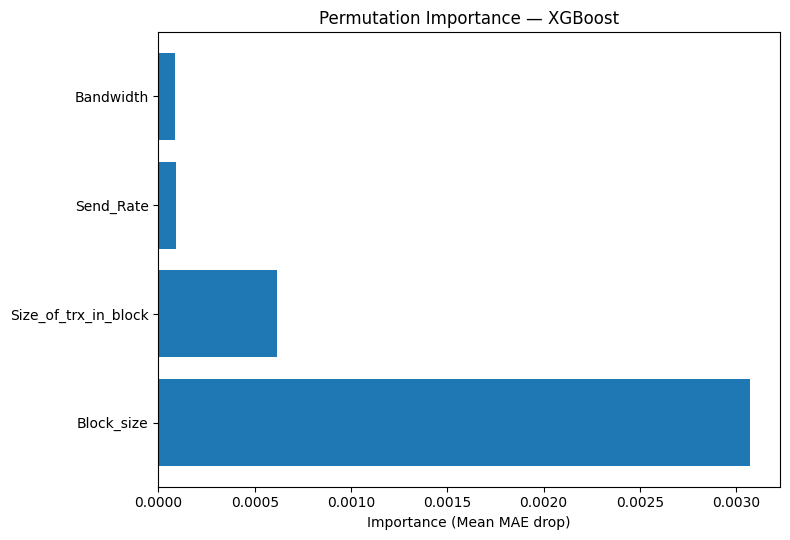

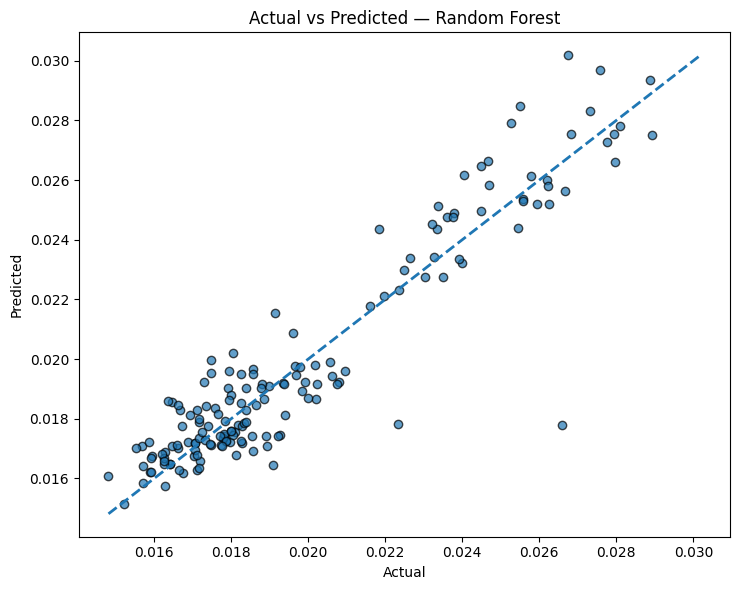

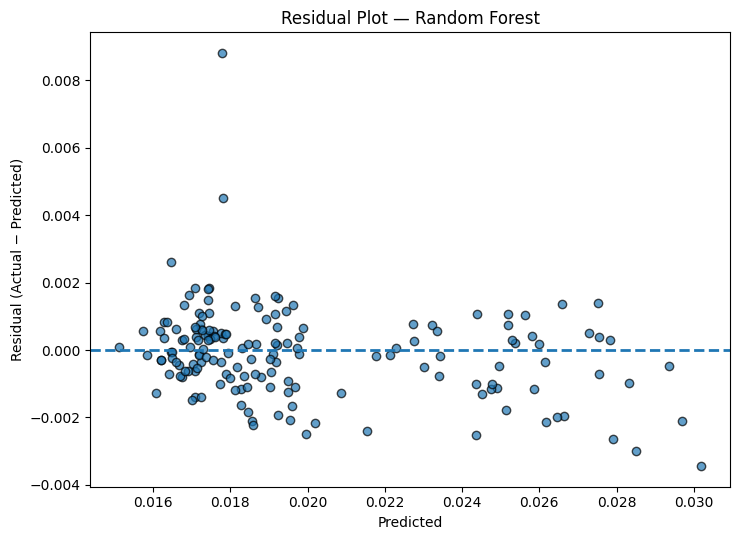

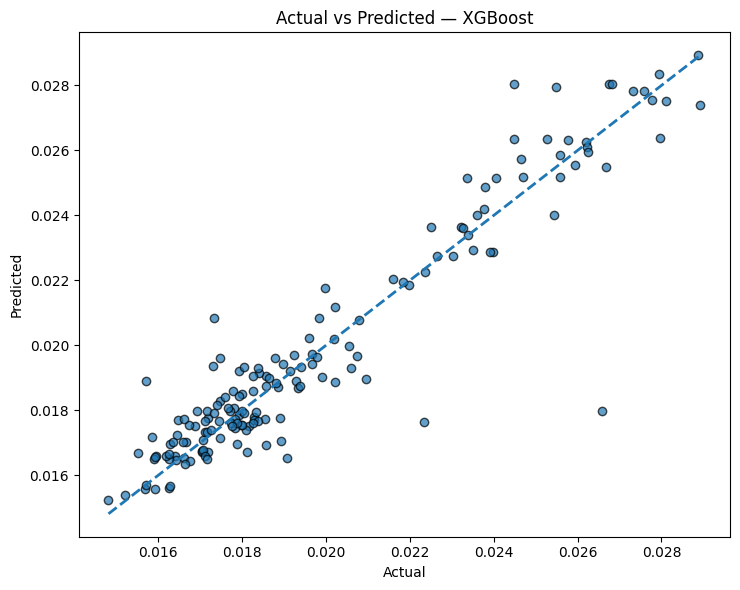

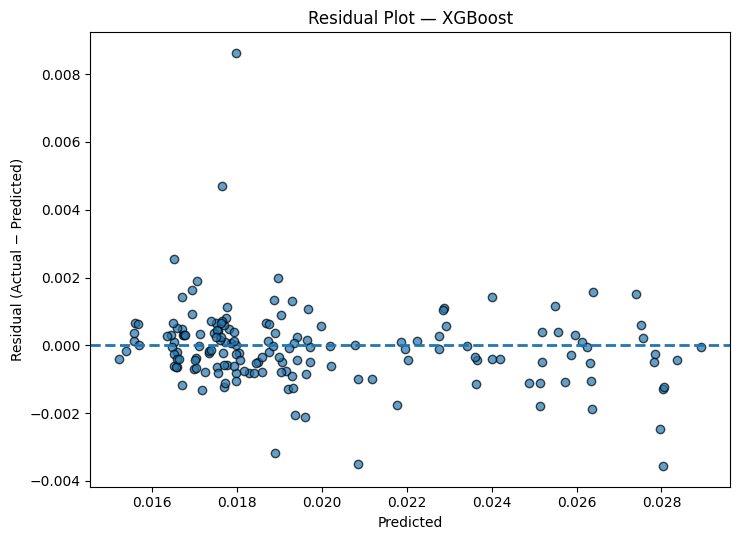

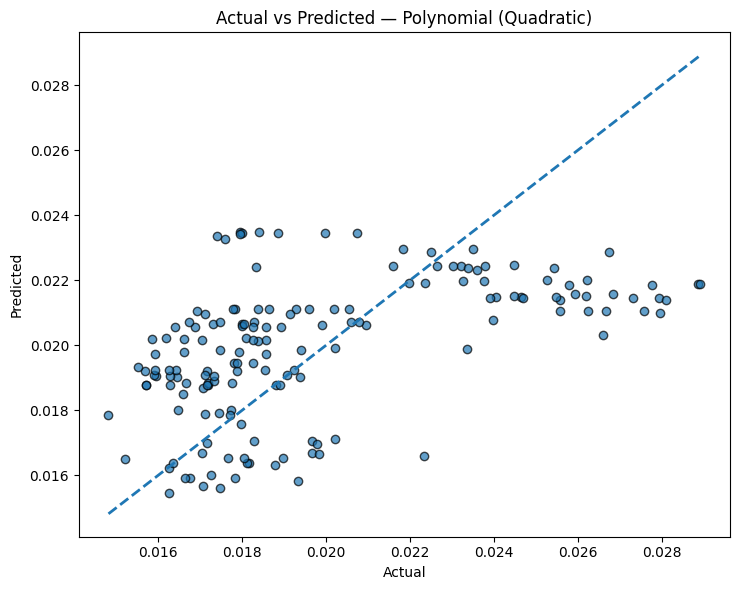

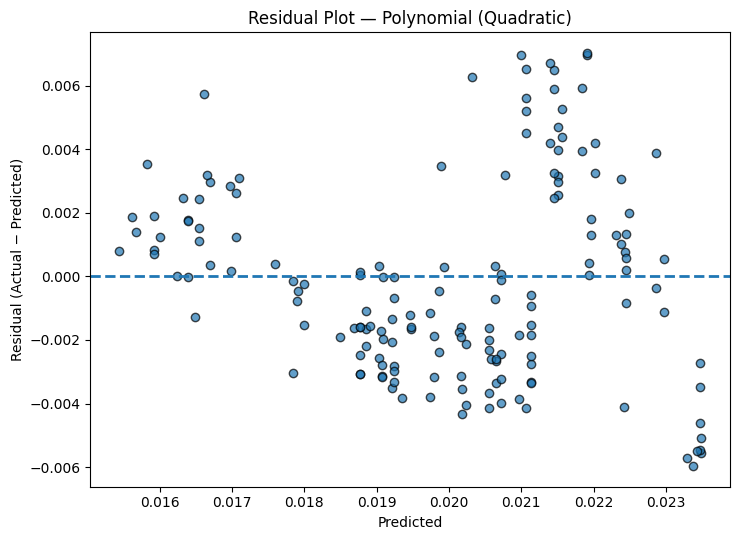

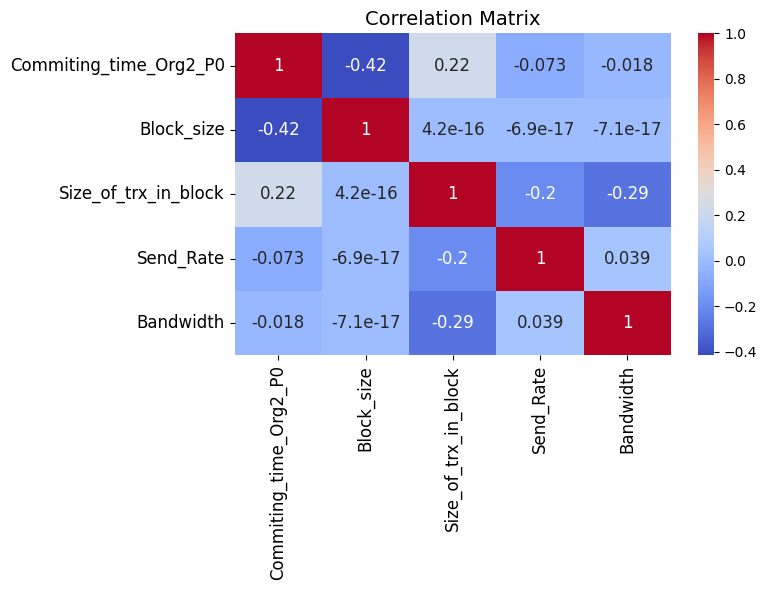

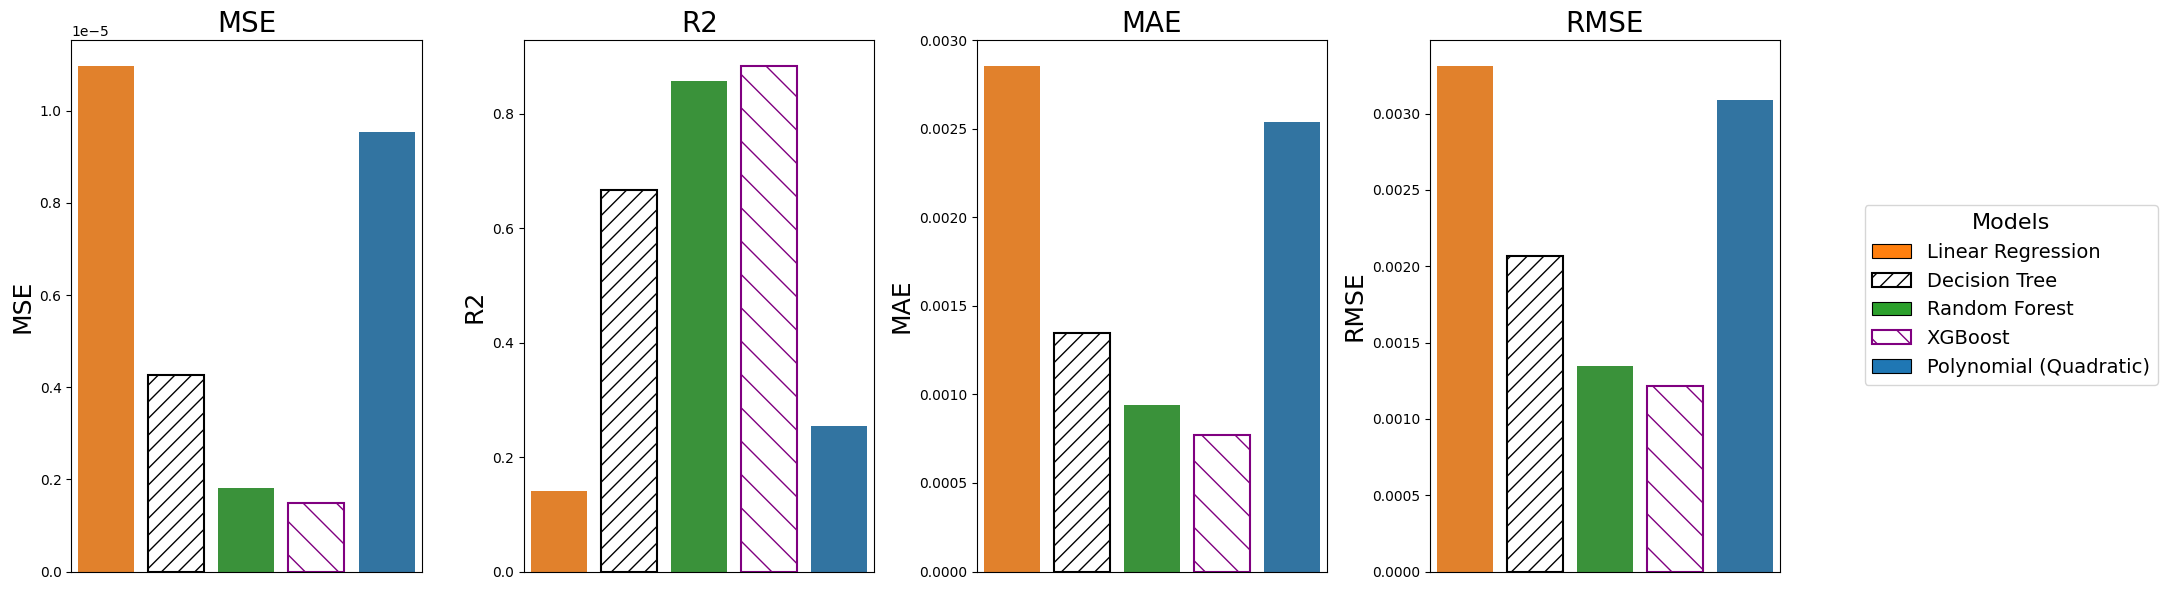

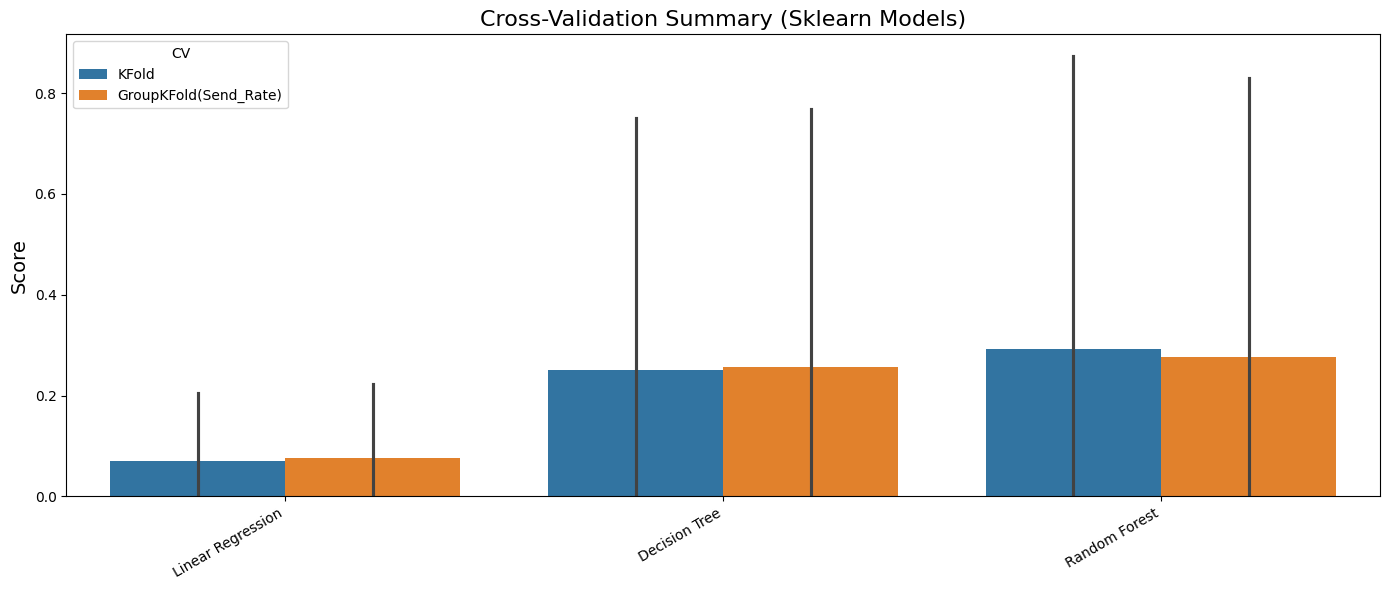


Saved models and quadratic artifacts successfully.


In [4]:
 #all model for peer0-Org1 validation time v2  


"""
Model comparison for Commiting_time_Org2_P0 (Org1 Peer0)

Goals (publication-friendly):
1) Train multiple regression models on the same feature set.
2) Report test-set metrics (MAE, RMSE, MSE, R2, MAPE) + simple baselines.
3) Run cross-validation:
   - KFold (random) for overall stability
   - GroupKFold (group by Send_Rate) to test generalization to unseen workload rates
4) Provide clean, consistent, high-quality plots:
   - Actual vs Predicted
   - Residual plots (diagnostic)
   - Metric comparison bars (MSE/R2/MAPE and MAE/RMSE/R2)
   - CV summary plot (MAE/RMSE/R2 from KFold and GroupKFold)

Notes on scaling:
- Tree-based models (DecisionTree/RandomForest/XGBoost) do NOT require feature scaling.
- Linear regression benefits from scaling only when regularization is used; plain LinearRegression is fine.
- Quadratic curve_fit DOES benefit from scaling (we scale only inside that block, without leakage).

Assumptions:
- df is already loaded and contains:
  Block_size, Size_of_trx_in_block, Send_Rate, Bandwidth, Commiting_time_Org2_P0
"""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Commiting_time_Org2_P0'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance 
# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])
perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea )
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "MSE", "R2", "MAE", "RMSE"]],
    metric_names=["MSE", "R2", "MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)


# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "CP0Org2_linear_model.pkl")
joblib.dump(models["Decision Tree"], "CP0Org2_tree_model.pkl")
joblib.dump(models["Random Forest"], "CP0Org2_forest_model.pkl")
joblib.dump(models["XGBoost"], "CP0Org2_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "CP0Org2_quadratic_params.pkl")
joblib.dump(scaler_quad, "CP0Org2_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

